In [2]:

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score, jaccard_score, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Conv2DTranspose,
                                     concatenate, Activation, BatchNormalization,
                                     Add, Multiply,UpSampling2D)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


IMAGE_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 25

2026-04-18 18:06:50.878892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776535611.103052      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776535611.179831      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
train_image_path = "/kaggle/input/landslide-divided/dataset/train/images"
train_mask_path  = "/kaggle/input/landslide-divided/dataset/train/masks"
val_image_path   = "/kaggle/input/landslide-divided/dataset/validation/images"
val_mask_path    = "/kaggle/input/landslide-divided/dataset/validation/masks"
test_image_path  = "/kaggle/input/landslide-divided/dataset/test/images"
test_mask_path   = "/kaggle/input/landslide-divided/dataset/test/masks"

In [4]:


def read_image(path):
    x = cv2.imread(path, cv2.IMREAD_COLOR)
    # convert BGR -> RGB for visualization consistency (optional)
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    x = cv2.resize(x, (IMAGE_SIZE, IMAGE_SIZE))
    x = x.astype(np.float32) / 255.0
    return x

def read_mask(path):
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    x = cv2.resize(x, (IMAGE_SIZE, IMAGE_SIZE))
    x = x.astype(np.float32) / 255.0
    x = np.expand_dims(x, axis=-1)
    return x

class DataGen(Sequence):
    def __init__(self, image_paths, mask_paths, batch_size=BATCH_SIZE, shuffle=True):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return max(1, len(self.image_paths) // self.batch_size)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        images = [read_image(self.image_paths[i]) for i in batch_idx]
        masks  = [read_mask(self.mask_paths[i]) for i in batch_idx]
        return np.array(images), np.array(masks)

    def on_epoch_end(self):
        self.indices = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)
# file lists and generators
train_images = sorted(glob(os.path.join(train_image_path, "*")))
train_masks  = sorted(glob(os.path.join(train_mask_path, "*")))
val_images   = sorted(glob(os.path.join(val_image_path, "*")))
val_masks    = sorted(glob(os.path.join(val_mask_path, "*")))
test_images  = sorted(glob(os.path.join(test_image_path, "*")))
test_masks   = sorted(glob(os.path.join(test_mask_path, "*")))

train_gen = DataGen(train_images, train_masks, BATCH_SIZE)#, shuffle=True)
val_gen   = DataGen(val_images, val_masks, BATCH_SIZE)#, shuffle=False)

print(f"Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")

Train: 1385, Val: 396, Test: 199


In [5]:

def attention_gate(x, g, inter_channels):
    theta_x = Conv2D(inter_channels, 1, padding='same')(x)   # skip connection
    phi_g = Conv2D(inter_channels, 1, padding='same')(g)
    # 🔹 Resize gating signal
    if theta_x.shape[1] is not None and phi_g.shape[1] is not None:
        if theta_x.shape[1] != phi_g.shape[1]:
            scale_h = theta_x.shape[1] // phi_g.shape[1]
            scale_w = theta_x.shape[2] // phi_g.shape[2]
            phi_g = UpSampling2D(size=(scale_h, scale_w), interpolation="bilinear")(phi_g)
    add_xg = Add()([theta_x, phi_g])
    act = Activation('relu')(add_xg)
    psi = Conv2D(1, 1, padding='same')(act)
    psi = Activation('sigmoid')(psi)
    return Multiply()([x, psi])
# Attention U-Net Model
def attention_unet(input_size=(IMAGE_SIZE, IMAGE_SIZE, 3)):
    inputs = Input(input_size)
    # Encoder
    c1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D()(c3)
    c4 = Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = Conv2D(512, 3, activation='relu', padding='same')(c4)
    p4 = MaxPooling2D()(c4)
    # Bottleneck
    c5 = Conv2D(1024, 3, activation='relu', padding='same')(p4)
    c5 = Conv2D(1024, 3, activation='relu', padding='same')(c5)
    # Decoder with Attention
    g4 = Conv2D(512, 1, activation='relu', padding='same')(c5)
    att4 = attention_gate(c4, g4, 256)
    u6 = Conv2DTranspose(512, 2, strides=2, padding='same')(c5)
    u6 = concatenate([u6, att4])
    c6 = Conv2D(512, 3, activation='relu', padding='same')(u6)
    c6 = Conv2D(512, 3, activation='relu', padding='same')(c6)
    g3 = Conv2D(256, 1, activation='relu', padding='same')(c6)
    att3 = attention_gate(c3, g3, 128)
    u7 = Conv2DTranspose(256, 2, strides=2, padding='same')(c6)
    u7 = concatenate([u7, att3])
    c7 = Conv2D(256, 3, activation='relu', padding='same')(u7)
    c7 = Conv2D(256, 3, activation='relu', padding='same')(c7)
    g2 = Conv2D(128, 1, activation='relu', padding='same')(c7)
    att2 = attention_gate(c2, g2, 64)
    u8 = Conv2DTranspose(128, 2, strides=2, padding='same')(c7)
    u8 = concatenate([u8, att2])
    c8 = Conv2D(128, 3, activation='relu', padding='same')(u8)
    c8 = Conv2D(128, 3, activation='relu', padding='same')(c8)
    g1 = Conv2D(64, 1, activation='relu', padding='same')(c8)
    att1 = attention_gate(c1, g1, 32)
    u9 = Conv2DTranspose(64, 2, strides=2, padding='same')(c8)
    u9 = concatenate([u9, att1])
    c9 = Conv2D(64, 3, activation='relu', padding='same')(u9)
    c9 = Conv2D(64, 3, activation='relu', padding='same')(c9)
    outputs = Conv2D(1, 1, activation='sigmoid')(c9)
    return Model(inputs, outputs, name="Attention_U-Net")
# Step 5: Compile & Train
model = attention_unet()
model.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS)


I0000 00:00:1776535663.436467      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776535663.439329      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1776535679.233896     104 service.cc:148] XLA service 0x7999a4016220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776535679.235176     104 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776535679.235198     104 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776535680.756138     104 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-04-18 18:08:05.989467: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng12{k11=0} for conv (f32[8,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,128,128,128]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_s

173/173 ━━━━━━━━━━━━━━━━━━━━ 207s 786ms/step - accuracy: 0.9154 - loss: 0.3886 - val_accuracy: 0.9538 - val_loss: 0.0949
Epoch 2/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 117s 679ms/step - accuracy: 0.9486 - loss: 0.0994 - val_accuracy: 0.9549 - val_loss: 0.0907
Epoch 3/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 118s 683ms/step - accuracy: 0.9506 - loss: 0.0963 - val_accuracy: 0.9558 - val_loss: 0.0812
Epoch 4/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 118s 680ms/step - accuracy: 0.9474 - loss: 0.0959 - val_accuracy: 0.9569 - val_loss: 0.0766
Epoch 5/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 118s 679ms/step - accuracy: 0.9491 - loss: 0.0914 - val_accuracy: 0.9553 - val_loss: 0.0793
Epoch 6/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 117s 676ms/step - accuracy: 0.9510 - loss: 0.0866 - val_accuracy: 0.9574 - val_loss: 0.0763
Epoch 7/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 117s 675ms/step - accuracy: 0.9501 - loss: 0.0890 - val_accuracy: 0.9542 - val_loss: 0.0809
Epoch 8/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 117s 674ms/step - accuracy: 0.9482 - loss: 0.09

In [6]:
model.summary()

Model: "Attention_U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 16, 16,    │    524,800 │ conv2d_9[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │    131,328 │ conv2d_10[0][0] 

 Total params: 96,235,889 (367.11 MB)

 Trainable params: 32,078,629 (122.37 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64,157,260 (244.74 MB)

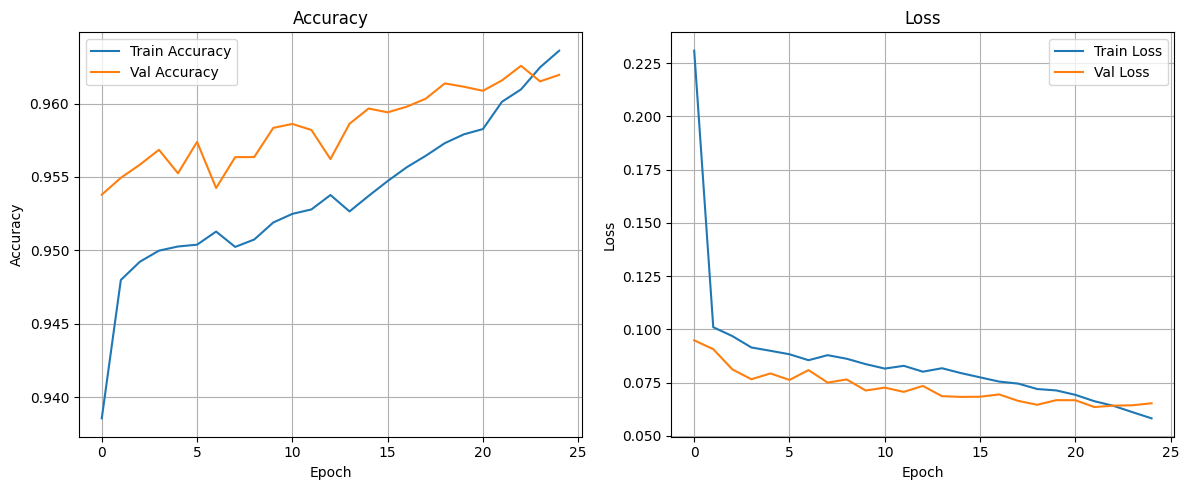

In [7]:

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid()

plt.tight_layout(); plt.show()


In [8]:


# get final train/val numbers from history
final_train_acc = history.history['accuracy'][-1]
final_train_loss = history.history['loss'][-1]
#final_val_acc = history.history['val_accuracy'][-1]
#final_val_loss = history.history['val_loss'][-1]
print(f"Train Accuracy: {final_train_acc:.4f}, Train Loss: {final_train_loss:.4f}")
#print(f"Final Val   Acc: {final_val_acc:.4f}, Val   Loss: {final_val_loss:.4f}")
test_gen = DataGen(test_images, test_masks, BATCH_SIZE, shuffle=False)
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f},Test Loss: {test_loss:.4f}")



Train Accuracy: 0.9636, Train Loss: 0.0583
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.9523 - loss: 0.0880

Test Accuracy: 0.9542,Test Loss: 0.0819


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━

<Figure size 500x500 with 0 Axes>

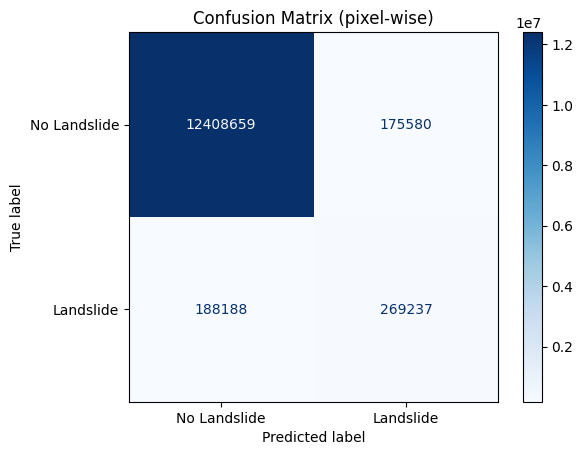

In [9]:

def dice_coef_flat(y_true, y_pred):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    inter = np.sum(y_true_f * y_pred_f)
    return (2. * inter) / (np.sum(y_true_f) + np.sum(y_pred_f) + 1e-7)

y_true_all = []
y_pred_all = []

for i in range(len(test_images)):
    img = read_image(test_images[i])
    mask = read_mask(test_masks[i])  # H,W,1
    prob = model.predict(np.expand_dims(img, 0))[0, ..., 0]  # H,W float
    pred_bin = (prob > 0.5).astype(np.uint8)

    y_true_all.extend(mask.flatten())
    y_pred_all.extend(pred_bin.flatten())

y_true_all = np.array(y_true_all, dtype=np.uint8)
y_pred_all = np.array(y_pred_all, dtype=np.uint8)

# classification report
print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_all, target_names=['No Landslide','Landslide'], digits=4))

# pixel-wise metrics
acc = accuracy_score(y_true_all, y_pred_all)
precision = precision_score(y_true_all, y_pred_all, zero_division=0)
recall = recall_score(y_true_all, y_pred_all, zero_division=0)
f1 = f1_score(y_true_all, y_pred_all, zero_division=0)
iou = jaccard_score(y_true_all, y_pred_all, zero_division=0)
dice = dice_coef_flat(y_true_all, y_pred_all)

print("\nPixel-wise Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"IoU      : {iou:.4f}")
print(f"Dice     : {dice:.4f}")

# confusion matrix plot
cm = confusion_matrix(y_true_all, y_pred_all)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Landslide','Landslide'])
plt.figure(figsize=(5,5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix (pixel-wise)")
plt.show()

In [10]:
def calculate_area(mask):
    return np.sum(mask == 1)

def classify_severity(area):
    if area < 5000:
        return "Low"
    elif area < 20000:
        return "Medium"
    else:
        return "High"

def generate_heatmap(image, mask):
    heatmap = np.zeros_like(image)
    heatmap[:, :, 0] = mask.squeeze() * 255

    overlay = cv2.addWeighted(image.astype(np.float32), 0.7,
                              heatmap.astype(np.float32), 0.3, 0)
    return overlay

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


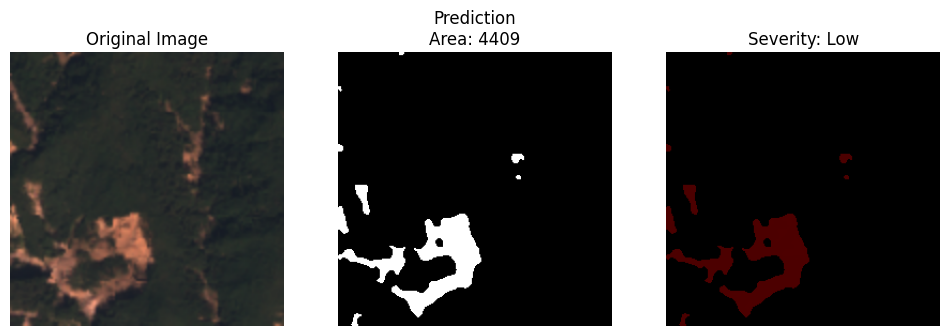

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


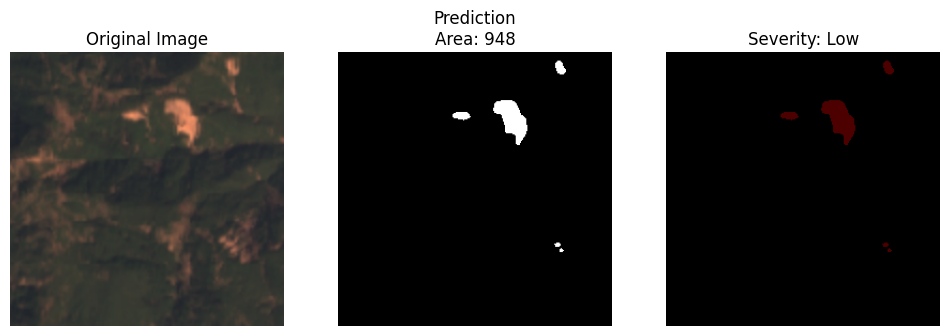

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


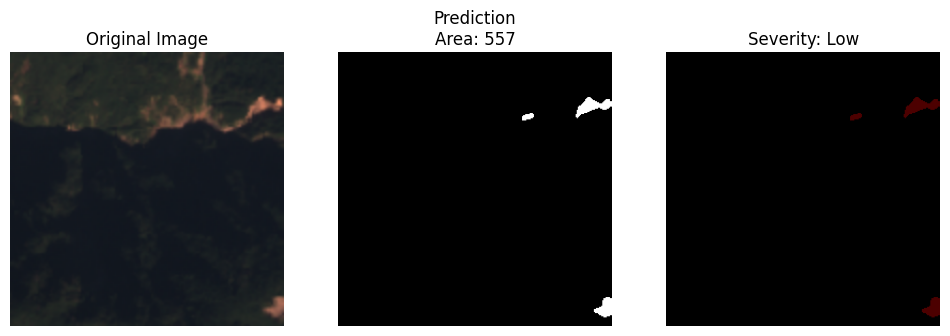

In [11]:

for i in range(3):   
    img = read_image(test_images[i])
    mask = read_mask(test_masks[i])

    pred = model.predict(np.expand_dims(img, axis=0))[0]
    pred = (pred > 0.5).astype(np.uint8)

    # Area
    area = calculate_area(pred)

    # Severity
    severity = classify_severity(area)

    # Heatmap
    heatmap = generate_heatmap(img, pred)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title(f"Prediction\nArea: {area}")
    plt.imshow(pred.squeeze(), cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"Severity: {severity}")
    plt.imshow(heatmap.astype(np.uint8))
    plt.axis("off")

    plt.show()